# High-Precision BOAMP Linkage Iteration

## tl;dr

Executed successfully. The high-precision automatic tier improved locked-test precision@1 from `0.250` to `0.438` and reduced false-positive rate on no-successor anchors from `0.441` to `0.237`, with coverage dropping from `0.564` to `0.410`. The manual-review tier preserves broad top-5 recall (`0.842`) but is not intended for automatic survival-analysis links.

## Context & Methods

The first weighted baseline over-linked no-successor anchors. Error analysis showed that many false positives had strong buyer/CPV/time evidence but weak text similarity. This iteration adds explicit acceptance gates: strong buyer evidence, meaningful text similarity, CPV/theme continuity unless text is very strong, and penalties for weak evidence. Tuning uses only `PILOT_DEVELOPMENT`; `LOCKED_TEST` is evaluated only after the config is frozen.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 220)
sns.set_theme(style="whitegrid", context="notebook")


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data/processed/boamp_grand_ouest/renewal_candidate_pairs.parquet").exists():
            return candidate
    return Path.cwd()

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data/processed/boamp_grand_ouest"
FIGURE_DIR = PROCESSED_DIR / "figures" / "high_precision_linkage"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PAIRS_PATH = PROCESSED_DIR / "renewal_candidate_pairs.parquet"
ANCHOR_PATH = PROCESSED_DIR / "reference_anchor_episodes.parquet"
LINKS_PATH = PROCESSED_DIR / "reference_successor_links.parquet"
BASELINE_RESULTS_PATH = PROCESSED_DIR / "linkage_evaluation_results.csv"
BASELINE_PREDICTIONS_PATH = PROCESSED_DIR / "linkage_baseline_predictions.parquet"
OUTPUT_PREDICTIONS_PATH = PROCESSED_DIR / "high_precision_linkage_predictions.parquet"
OUTPUT_EVALUATION_PATH = PROCESSED_DIR / "high_precision_linkage_evaluation.csv"
OUTPUT_CONFIG_PATH = PROCESSED_DIR / "high_precision_linkage_config.json"
OUTPUT_REVIEW_CANDIDATES_PATH = PROCESSED_DIR / "high_precision_review_candidates.csv"

print(PROJECT_ROOT)


/home/senghakrou/project-gigalis


## Data

### 1. Load Candidate Pairs And Benchmark Truth


In [2]:
def parse_json_list(value) -> list:
    if value is None or pd.isna(value):
        return []
    text = str(value).strip()
    if text == "":
        return []
    try:
        parsed = json.loads(text)
    except Exception:
        return []
    return parsed if isinstance(parsed, list) else [parsed]

pairs = pd.read_parquet(PAIRS_PATH)
anchors = pd.read_parquet(ANCHOR_PATH)
links = pd.read_parquet(LINKS_PATH)
baseline_results = pd.read_csv(BASELINE_RESULTS_PATH)
baseline_predictions = pd.read_parquet(BASELINE_PREDICTIONS_PATH)

eligible = anchors[anchors["primary_evaluation_eligible"].astype(str).eq("True")].copy()
eligible_ids = set(eligible["sample_id"])
pairs = pairs[pairs["sample_id"].isin(eligible_ids)].copy()

truth_by_sample = {sample_id: set() for sample_id in eligible["sample_id"]}
for row in links[links["sample_id"].isin(eligible_ids)].itertuples(index=False):
    truth_by_sample.setdefault(row.sample_id, set()).update(parse_json_list(row.successor_notice_ids_json))

truth = eligible[["sample_id", "benchmark_split", "anchor_episode_id", "final_outcome", "final_confidence"]].copy()
truth["true_successor_idwebs"] = truth["sample_id"].map(lambda sample_id: sorted(truth_by_sample.get(sample_id, set())))
truth["has_true_successor"] = truth["true_successor_idwebs"].map(bool)

print(f"Eligible anchors: {len(truth)}")
print(f"Candidate pairs: {len(pairs):,}")
display(pd.crosstab(truth["benchmark_split"], truth["has_true_successor"]))


Eligible anchors: 94
Candidate pairs: 6,443


has_true_successor,False,True
benchmark_split,,
LOCKED_TEST,59,19
PILOT_DEVELOPMENT,11,5


### 2. Define High-Precision Score And Gates


In [3]:
WEIGHTS = {
    "high_precision_v1": {"buyer": 0.40, "text": 0.30, "cpv": 0.15, "time": 0.10, "geo": 0.05},
    "text_precision_v1": {"buyer": 0.35, "text": 0.40, "cpv": 0.10, "time": 0.10, "geo": 0.05},
    "buyer_precision_v1": {"buyer": 0.50, "text": 0.25, "cpv": 0.15, "time": 0.05, "geo": 0.05},
}
BUYER_SCORE_MAP = {"siren": 1.0, "normalized_name": 0.9, "fuzzy_name": 0.7, "token_overlap": 0.6}


def add_high_precision_components(frame: pd.DataFrame, weights_name: str) -> pd.DataFrame:
    tmp = frame.copy()
    weights = WEIGHTS[weights_name]
    tmp["hp_buyer_score"] = tmp["buyer_match_type"].map(BUYER_SCORE_MAP).fillna(0).astype(float)
    tmp["hp_text_score"] = tmp[["word_tfidf_similarity", "char_ngram_tfidf_similarity"]].max(axis=1).fillna(0).clip(0, 1)
    tmp["hp_cpv_score"] = tmp["cpv_overlap_score"].fillna(0).clip(0, 1)
    tmp["hp_time_score"] = tmp["duration_gap_score"].fillna(0).clip(0, 1)
    tmp["hp_geo_score"] = tmp["same_region"].astype(bool).astype(float)
    tmp["hp_strong_buyer"] = tmp["buyer_match_type"].isin(["siren", "normalized_name"]) | (
        tmp["buyer_match_type"].isin(["fuzzy_name", "token_overlap"]) & tmp["buyer_name_similarity"].fillna(0).ge(0.82)
    )
    tmp["hp_score"] = 100 * (
        weights["buyer"] * tmp["hp_buyer_score"]
        + weights["text"] * tmp["hp_text_score"]
        + weights["cpv"] * tmp["hp_cpv_score"]
        + weights["time"] * tmp["hp_time_score"]
        + weights["geo"] * tmp["hp_geo_score"]
    )
    return tmp


def apply_high_precision_rules(frame: pd.DataFrame, config: dict) -> pd.DataFrame:
    tmp = add_high_precision_components(frame, config["weights"])
    base_gate = (
        tmp["hp_strong_buyer"]
        & tmp["time_gap_days"].between(config["min_gap_days"], config["max_gap_days"])
        & tmp["hp_text_score"].ge(config["min_text_similarity"])
        & tmp["hp_time_score"].ge(config["min_time_score"])
    )
    cpv_gate = tmp["hp_cpv_score"].gt(0) | tmp["same_theme"].astype(bool) | tmp["hp_text_score"].ge(config["text_override_for_missing_cpv"])
    fuzzy_penalty_gate = ~tmp["buyer_match_type"].isin(["fuzzy_name", "token_overlap"]) | (
        tmp["hp_text_score"].ge(config["min_text_for_fuzzy_buyer"])
        & (tmp["hp_cpv_score"].gt(0) | tmp["same_theme"].astype(bool))
    )
    tmp["automatic_gate_pass"] = base_gate & cpv_gate & fuzzy_penalty_gate & tmp["hp_score"].ge(config["automatic_threshold"])
    tmp["manual_review_gate_pass"] = (
        tmp["hp_strong_buyer"]
        & tmp["time_gap_days"].between(config["min_gap_days"], config["max_gap_days"])
        & (tmp["hp_text_score"].ge(config["manual_review_min_text"]) | tmp["hp_cpv_score"].gt(0) | tmp["same_theme"].astype(bool))
        & tmp["hp_score"].ge(config["manual_review_threshold"])
    )
    tmp["link_decision"] = np.select(
        [tmp["automatic_gate_pass"], tmp["manual_review_gate_pass"]],
        ["automatic_high_confidence_link", "manual_review_candidate"],
        default="no_link",
    )
    return tmp


def predictions_from_scored(scored: pd.DataFrame, decision_column: str = "automatic_gate_pass", top_k: int = 5) -> dict[str, list[str]]:
    predictions = {sample_id: [] for sample_id in truth["sample_id"]}
    accepted = scored[scored[decision_column]].sort_values("hp_score", ascending=False)
    for sample_id, group in accepted.groupby("sample_id"):
        predictions[sample_id] = group["candidate_idweb"].astype(str).head(top_k).tolist()
    return predictions


### 3. Define Evaluation


In [4]:
def evaluate_predictions(predictions: dict[str, list[str]], split: str | None = None) -> dict:
    eval_truth = truth if split is None else truth[truth["benchmark_split"].eq(split)]
    rows = []
    for row in eval_truth.itertuples(index=False):
        predicted = predictions.get(row.sample_id, []) or []
        predicted = [str(x) for x in predicted]
        true_set = set(row.true_successor_idwebs)
        has_true = bool(true_set)
        top1 = predicted[0] if predicted else None
        top1_correct = bool(top1 and top1 in true_set)
        top5_correct = bool(true_set and any(candidate in true_set for candidate in predicted[:5]))
        rr = 0.0
        if true_set:
            for rank, candidate in enumerate(predicted, start=1):
                if candidate in true_set:
                    rr = 1.0 / rank
                    break
        rows.append({
            "sample_id": row.sample_id,
            "split": row.benchmark_split,
            "has_true_successor": has_true,
            "predicted_any": bool(predicted),
            "top1_correct": top1_correct,
            "top5_correct": top5_correct,
            "false_positive_no_successor": (not has_true and bool(predicted)),
            "no_link_correct": (not has_true and not predicted),
            "reciprocal_rank": rr,
        })
    frame = pd.DataFrame(rows)
    predicted_count = int(frame["predicted_any"].sum())
    positive_count = int(frame["has_true_successor"].sum())
    no_successor_count = int((~frame["has_true_successor"]).sum())
    return {
        "anchors": int(len(frame)),
        "positive_anchors": positive_count,
        "no_successor_anchors": no_successor_count,
        "coverage_rate": float(frame["predicted_any"].mean()) if len(frame) else 0.0,
        "precision_at_1": float(frame["top1_correct"].sum() / predicted_count) if predicted_count else 0.0,
        "recall_at_1": float(frame["top1_correct"].sum() / positive_count) if positive_count else 0.0,
        "recall_at_5": float(frame["top5_correct"].sum() / positive_count) if positive_count else 0.0,
        "mean_reciprocal_rank": float(frame["reciprocal_rank"].mean()) if len(frame) else 0.0,
        "false_positive_rate_no_successor": float(frame["false_positive_no_successor"].sum() / no_successor_count) if no_successor_count else 0.0,
        "no_link_accuracy": float(frame["no_link_correct"].sum() / no_successor_count) if no_successor_count else 0.0,
        "predicted_count": predicted_count,
    }


def high_precision_objective(metrics: dict) -> float:
    if metrics["predicted_count"] == 0:
        return -1.0
    return 0.70 * metrics["precision_at_1"] + 0.20 * metrics["no_link_accuracy"] + 0.10 * metrics["recall_at_5"]


## Results

### 4. Tune High-Precision Gates On Pilot Development Only


In [5]:
CONFIG_GRID = []
for weights in ["high_precision_v1", "text_precision_v1", "buyer_precision_v1"]:
    for automatic_threshold in [60, 65, 70, 75, 80, 85]:
        for min_text_similarity in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
            for text_override_for_missing_cpv in [0.45, 0.55, 0.65, 0.75]:
                for min_time_score in [0.0, 0.15, 0.30]:
                    CONFIG_GRID.append({
                        "weights": weights,
                        "automatic_threshold": automatic_threshold,
                        "min_text_similarity": min_text_similarity,
                        "text_override_for_missing_cpv": text_override_for_missing_cpv,
                        "min_text_for_fuzzy_buyer": max(0.45, min_text_similarity + 0.10),
                        "min_time_score": min_time_score,
                        "min_gap_days": 180,
                        "max_gap_days": 8 * 365,
                        "manual_review_threshold": 45,
                        "manual_review_min_text": 0.10,
                        "top_k": 5,
                    })

tuning_records = []
for config_id, cfg in enumerate(CONFIG_GRID):
    scored = apply_high_precision_rules(pairs, cfg)
    predictions = predictions_from_scored(scored, "automatic_gate_pass", top_k=cfg["top_k"])
    metrics = evaluate_predictions(predictions, split="PILOT_DEVELOPMENT")
    tuning_records.append({
        "config_id": config_id,
        "config_json": json.dumps(cfg, ensure_ascii=False),
        **metrics,
        "objective": high_precision_objective(metrics),
        "tie_break_text_similarity": cfg["min_text_similarity"],
        "tie_break_threshold": cfg["automatic_threshold"],
        "tie_break_time_score": cfg["min_time_score"],
    })

tuning_df = pd.DataFrame(tuning_records)
selected_row = (
    tuning_df[tuning_df["predicted_count"].ge(2)]
    .sort_values(["objective", "precision_at_1", "no_link_accuracy", "recall_at_5", "tie_break_text_similarity", "tie_break_threshold"], ascending=False)
    .iloc[0]
)
selected_config = json.loads(selected_row["config_json"])
print("Selected config from PILOT_DEVELOPMENT only:")
print(json.dumps(selected_config, indent=2, ensure_ascii=False))
display(tuning_df.sort_values(["objective", "precision_at_1", "no_link_accuracy"], ascending=False).head(12))


Selected config from PILOT_DEVELOPMENT only:
{
  "weights": "buyer_precision_v1",
  "automatic_threshold": 65,
  "min_text_similarity": 0.25,
  "text_override_for_missing_cpv": 0.55,
  "min_text_for_fuzzy_buyer": 0.45,
  "min_time_score": 0.0,
  "min_gap_days": 180,
  "max_gap_days": 2920,
  "manual_review_threshold": 45,
  "manual_review_min_text": 0.1,
  "top_k": 5
}


,config_id,config_json,anchors,positive_anchors,no_successor_anchors,coverage_rate,precision_at_1,recall_at_1,recall_at_5,mean_reciprocal_rank,false_positive_rate_no_successor,no_link_accuracy,predicted_count,objective,tie_break_text_similarity,tie_break_threshold,tie_break_time_score
522,522,"{""weights"": ""text_precision_v1"", ""automatic_threshold"": 60, ""min_text_similarity"": 0.25, ""text_override_for_missing_cpv"": 0.65, ""min_text_for_fuzzy_buyer"": 0.45, ""min_time_score"": 0.0, ""min_gap_days"": 180, ""max_gap_d...",16,5,11,0.3125,0.80,0.8,1.0,0.270833,0.0,1.0,5,0.860,0.25,60,0.0
525,525,"{""weights"": ""text_precision_v1"", ""automatic_threshold"": 60, ""min_text_similarity"": 0.25, ""text_override_for_missing_cpv"": 0.75, ""min_text_for_fuzzy_buyer"": 0.45, ""min_time_score"": 0.0, ""min_gap_days"": 180, ""max_gap_d...",16,5,11,0.3125,0.80,0.8,1.0,0.270833,0.0,1.0,5,0.860,0.25,60,0.0
1107,1107,"{""weights"": ""buyer_precision_v1"", ""automatic_threshold"": 65, ""min_text_similarity"": 0.25, ""text_override_for_missing_cpv"": 0.55, ""min_text_for_fuzzy_buyer"": 0.45, ""min_time_score"": 0.0, ""min_gap_days"": 180, ""max_gap_...",16,5,11,0.3125,0.80,0.8,1.0,0.270833,0.0,1.0,5,0.860,0.25,65,0.0
24,24,"{""weights"": ""high_precision_v1"", ""automatic_threshold"": 60, ""min_text_similarity"": 0.3, ""text_override_for_missing_cpv"": 0.45, ""min_text_for_fuzzy_buyer"": 0.45, ""min_time_score"": 0.0, ""min_gap_days"": 180, ""max_gap_da...",16,5,11,0.2500,0.75,0.6,0.8,0.208333,0.0,1.0,4,0.805,0.30,60,0.0
30,30,"{""weights"": ""high_precision_v1"", ""automatic_threshold"": 60, ""min_text_similarity"": 0.3, ""text_override_for_missing_cpv"": 0.65, ""min_text_for_fuzzy_buyer"": 0.45, ""min_time_score"": 0.0, ""min_gap_days"": 180, ""max_gap_da...",16,5,11,0.2500,0.75,0.6,0.8,0.208333,0.0,1.0,4,0.805,0.30,60,0.0
33,33,"{""weights"": ""high_precision_v1"", ""automatic_threshold"": 60, ""min_text_similarity"": 0.3, ""text_override_for_missing_cpv"": 0.75, ""min_text_for_fuzzy_buyer"": 0.45, ""min_time_score"": 0.0, ""min_gap_days"": 180, ""max_gap_da...",16,5,11,0.2500,0.75,0.6,0.8,0.208333,0.0,1.0,4,0.805,0.30,60,0.0
39,39,"{""weights"": ""high_precision_v1"", ""automatic_threshold"": 60, ""min_text_similarity"": 0.35, ""text_override_for_missing_cpv"": 0.55, ""min_text_for_fuzzy_buyer"": 0.45, ""min_time_score"": 0.0, ""min_gap_days"": 180, ""max_gap_d...",16,5,11,0.2500,0.75,0.6,0.8,0.208333,0.0,1.0,4,0.805,0.35,60,0.0
51,51,"{""weights"": ""high_precision_v1"", ""automatic_threshold"": 60, ""min_text_similarity"": 0.4, ""text_override_for_missing_cpv"": 0.55, ""min_text_for_fuzzy_buyer"": 0.5, ""min_time_score"": 0.0, ""min_gap_days"": 180, ""max_gap_day...",16,5,11,0.2500,0.75,0.6,0.8,0.208333,0.0,1.0,4,0.805,0.40,60,0.0
84,84,"{""weights"": ""high_precision_v1"", ""automatic_threshold"": 65, ""min_text_similarity"": 0.2, ""text_override_for_missing_cpv"": 0.45, ""min_text_for_fuzzy_buyer"": 0.45, ""min_time_score"": 0.0, ""min_gap_days"": 180, ""max_gap_da...",16,5,11,0.2500,0.75,0.6,0.8,0.208333,0.0,1.0,4,0.805,0.20,65,0.0
87,87,"{""weights"": ""high_precision_v1"", ""automatic_threshold"": 65, ""min_text_similarity"": 0.2, ""text_override_for_missing_cpv"": 0.55, ""min_text_for_fuzzy_buyer"": 0.45, ""min_time_score"": 0.0, ""min_gap_days"": 180, ""max_gap_da...",16,5,11,0.2500,0.75,0.6,0.8,0.208333,0.0,1.0,4,0.805,0.20,65,0.0


### 5. Evaluate Frozen High-Precision Iteration


In [6]:
selected_scored_pairs = apply_high_precision_rules(pairs, selected_config)
automatic_predictions = predictions_from_scored(selected_scored_pairs, "automatic_gate_pass", top_k=selected_config["top_k"])
review_predictions = predictions_from_scored(selected_scored_pairs, "manual_review_gate_pass", top_k=selected_config["top_k"])

prediction_rows = []
for row in truth.itertuples(index=False):
    auto_pred = automatic_predictions.get(row.sample_id, []) or []
    review_pred = review_predictions.get(row.sample_id, []) or []
    true_set = set(row.true_successor_idwebs)
    prediction_rows.append({
        "model": "M6_high_precision_gated_score",
        "sample_id": row.sample_id,
        "benchmark_split": row.benchmark_split,
        "anchor_episode_id": row.anchor_episode_id,
        "final_outcome": row.final_outcome,
        "true_successor_idwebs_json": json.dumps(row.true_successor_idwebs, ensure_ascii=False),
        "automatic_predicted_idwebs_json": json.dumps(auto_pred, ensure_ascii=False),
        "manual_review_predicted_idwebs_json": json.dumps(review_pred, ensure_ascii=False),
        "top1_automatic_idweb": auto_pred[0] if auto_pred else "",
        "automatic_link_decision": "automatic_high_confidence_link" if auto_pred else "no_link",
        "automatic_top1_correct": bool(auto_pred and auto_pred[0] in true_set),
        "automatic_top5_correct": bool(true_set and any(candidate in true_set for candidate in auto_pred[:5])),
        "review_top5_contains_truth": bool(true_set and any(candidate in true_set for candidate in review_pred[:5])),
    })
predictions_df = pd.DataFrame(prediction_rows)
predictions_df.to_parquet(OUTPUT_PREDICTIONS_PATH, index=False, compression="zstd")

evaluation_records = []
for split in ["PILOT_DEVELOPMENT", "LOCKED_TEST", "ALL_ELIGIBLE"]:
    metrics = evaluate_predictions(automatic_predictions, split=None if split == "ALL_ELIGIBLE" else split)
    evaluation_records.append({"model": "M6_high_precision_gated_score", "prediction_tier": "automatic", "split": split, **metrics})
    review_metrics = evaluate_predictions(review_predictions, split=None if split == "ALL_ELIGIBLE" else split)
    evaluation_records.append({"model": "M6_high_precision_gated_score", "prediction_tier": "manual_review_top5", "split": split, **review_metrics})

baseline_selected = baseline_results[baseline_results["config_id"].astype(str).eq("selected")].copy()
baseline_selected = baseline_selected[baseline_selected["algorithm"].eq("M3_weighted_rule_score")]
for row in baseline_selected.itertuples(index=False):
    evaluation_records.append({
        "model": "M3_weighted_rule_score_baseline",
        "prediction_tier": "automatic_baseline",
        "split": row.split,
        "anchors": row.anchors,
        "positive_anchors": row.positive_anchors,
        "no_successor_anchors": row.no_successor_anchors,
        "coverage_rate": row.coverage_rate,
        "precision_at_1": row.precision_at_1,
        "recall_at_1": row.recall_at_1,
        "recall_at_5": row.recall_at_5,
        "mean_reciprocal_rank": row.mean_reciprocal_rank,
        "false_positive_rate_no_successor": row.false_positive_rate_no_successor,
        "no_link_accuracy": row.no_link_accuracy,
        "predicted_count": row.predicted_count,
    })

evaluation_df = pd.DataFrame(evaluation_records)
evaluation_df.to_csv(OUTPUT_EVALUATION_PATH, index=False, encoding="utf-8")
display(evaluation_df[evaluation_df["split"].eq("LOCKED_TEST")].sort_values(["prediction_tier", "precision_at_1"], ascending=[True, False]))


,model,prediction_tier,split,anchors,positive_anchors,no_successor_anchors,coverage_rate,precision_at_1,recall_at_1,recall_at_5,mean_reciprocal_rank,false_positive_rate_no_successor,no_link_accuracy,predicted_count
2,M6_high_precision_gated_score,automatic,LOCKED_TEST,78,19,59,0.410256,0.437500,0.736842,0.842105,0.190171,0.237288,0.762712,32
7,M3_weighted_rule_score_baseline,automatic_baseline,LOCKED_TEST,78,19,59,0.564103,0.250000,0.578947,0.684211,0.151709,0.440678,0.559322,44
3,M6_high_precision_gated_score,manual_review_top5,LOCKED_TEST,78,19,59,0.987179,0.155844,0.631579,0.842105,0.177350,0.983051,0.016949,77


### 6. Save Manual-Review Candidate Table


In [7]:
review_cols = [
    "sample_id", "benchmark_split", "anchor_episode_id", "anchor_award_notice_date", "anchor_expected_end_date", "anchor_buyer_name", "anchor_theme",
    "anchor_text_normalized", "candidate_idweb", "candidate_dateparution", "candidate_buyer_name", "candidate_primary_cpv_prefix2", "candidate_technology_segment",
    "candidate_text_normalized", "url_avis", "time_gap_months", "buyer_match_type", "buyer_name_similarity", "buyer_token_overlap", "hp_score",
    "hp_buyer_score", "hp_text_score", "hp_cpv_score", "hp_time_score", "hp_geo_score", "automatic_gate_pass", "manual_review_gate_pass", "link_decision"
]
review_candidates = selected_scored_pairs[selected_scored_pairs["manual_review_gate_pass"]].sort_values(["sample_id", "hp_score"], ascending=[True, False]).copy()
review_candidates["candidate_rank_for_review"] = review_candidates.groupby("sample_id").cumcount() + 1
review_candidates = review_candidates[review_candidates["candidate_rank_for_review"].le(selected_config["top_k"])]
review_candidates[[c for c in ["candidate_rank_for_review", *review_cols] if c in review_candidates.columns]].to_csv(OUTPUT_REVIEW_CANDIDATES_PATH, index=False, encoding="utf-8")
print(f"Review candidates: {len(review_candidates):,}")
display(review_candidates[[c for c in ["sample_id", "benchmark_split", "candidate_rank_for_review", "candidate_idweb", "hp_score", "hp_text_score", "hp_cpv_score", "hp_time_score", "link_decision"] if c in review_candidates.columns]].head(20))


Review candidates: 441


,sample_id,benchmark_split,candidate_rank_for_review,candidate_idweb,hp_score,hp_text_score,hp_cpv_score,hp_time_score,link_decision
75,RV-002,PILOT_DEVELOPMENT,1,22-50332,60.542887,0.121852,0.333333,0.499315,manual_review_candidate
83,RV-002,PILOT_DEVELOPMENT,2,21-90944,59.522385,0.119252,0.333333,0.308219,manual_review_candidate
85,RV-002,PILOT_DEVELOPMENT,3,21-75704,59.494942,0.121852,0.333333,0.289726,manual_review_candidate
91,RV-002,PILOT_DEVELOPMENT,4,21-40468,59.186769,0.119252,0.333333,0.241096,manual_review_candidate
88,RV-002,PILOT_DEVELOPMENT,5,21-112471,58.453989,0.070077,0.333333,0.340411,manual_review_candidate
225,RV-004,PILOT_DEVELOPMENT,1,23-17061,73.334257,0.144329,1.000000,0.945205,manual_review_candidate
226,RV-004,PILOT_DEVELOPMENT,2,23-43054,70.150614,0.048764,1.000000,0.786301,manual_review_candidate
229,RV-004,PILOT_DEVELOPMENT,3,22-18409,69.459057,0.168499,1.000000,0.049315,manual_review_candidate
227,RV-004,PILOT_DEVELOPMENT,4,23-84503,69.123217,0.048764,1.000000,0.580822,manual_review_candidate
242,RV-004,PILOT_DEVELOPMENT,5,19-48030,66.097011,0.043880,1.000000,0.000000,manual_review_candidate


### 7. Visual Diagnostics


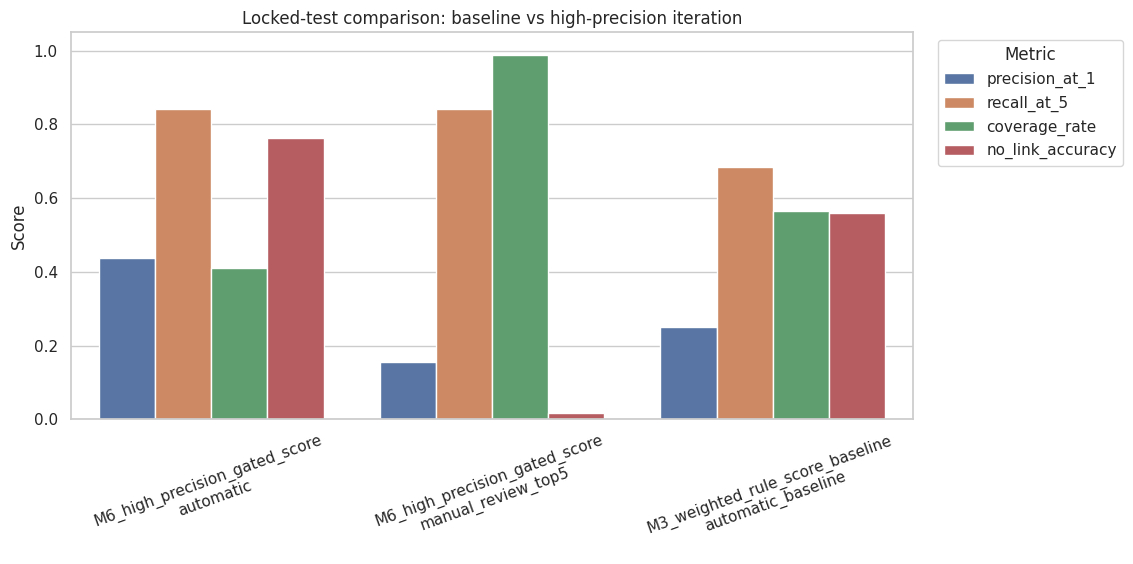

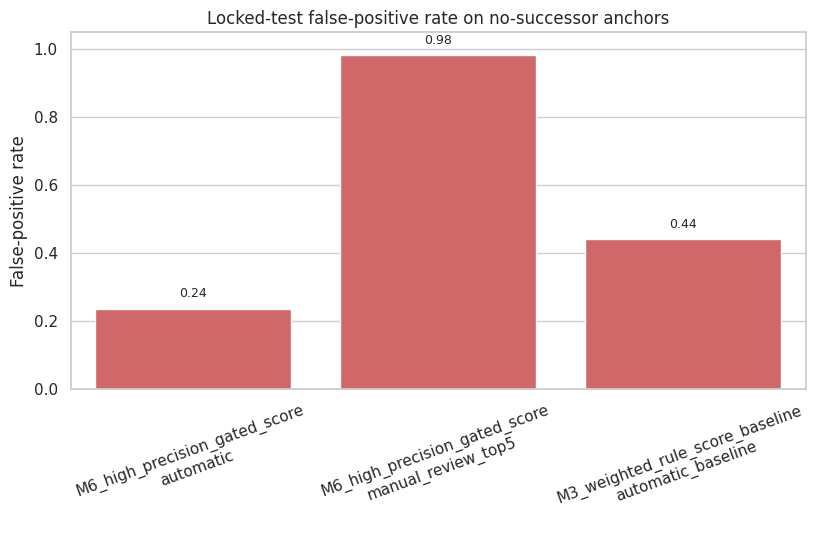

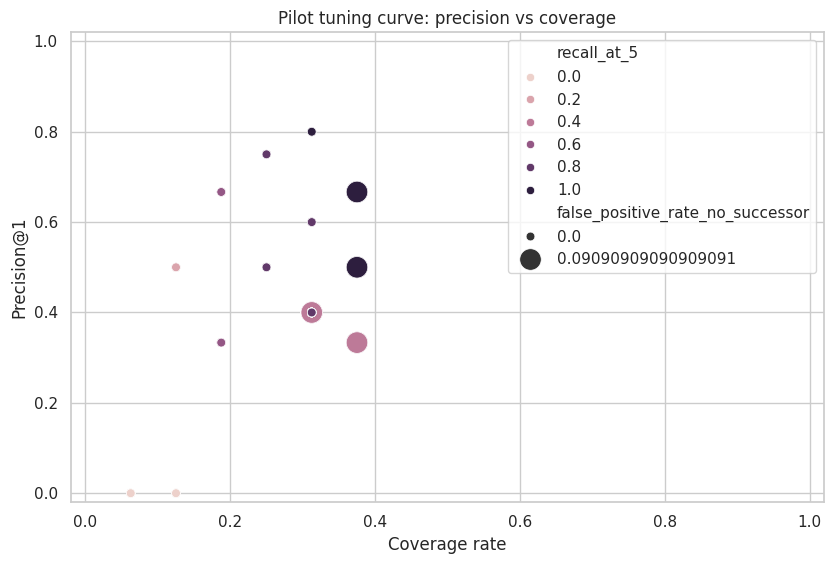

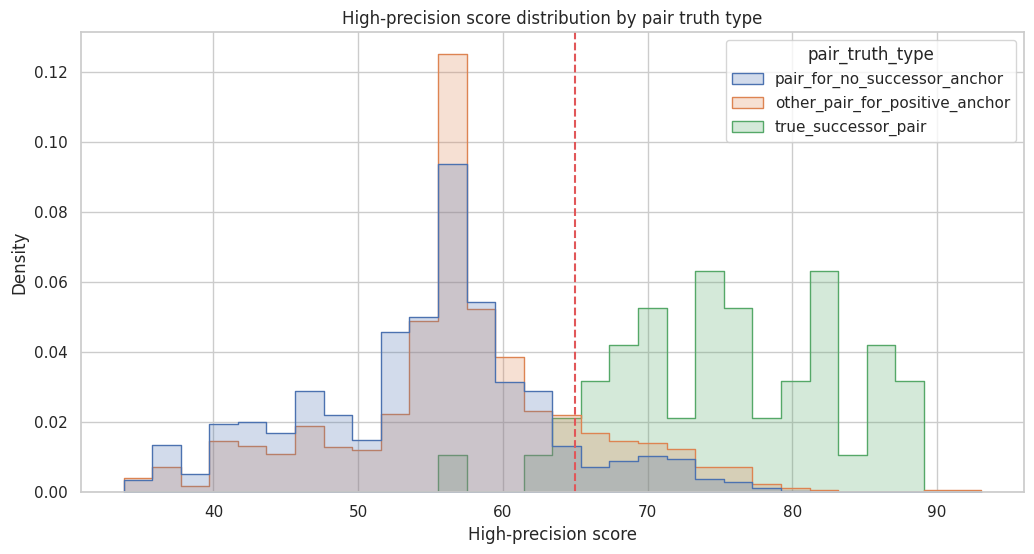

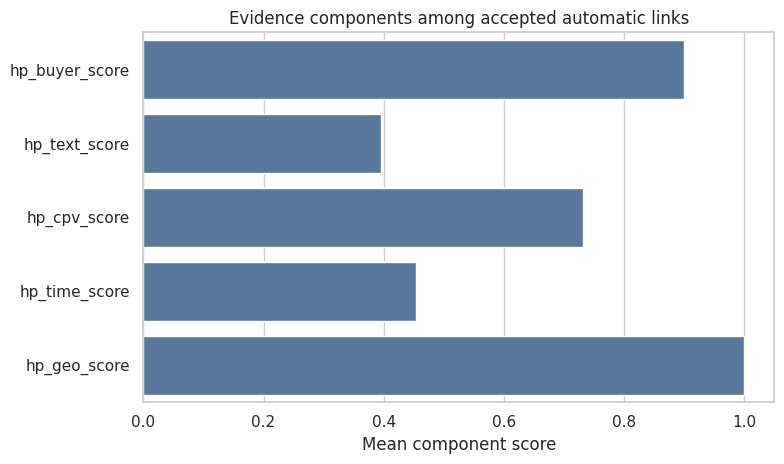

,figure,path
0,locked_test_baseline_vs_high_precision,/home/senghakrou/project-gigalis/data/processed/boamp_grand_ouest/figures/high_precision_linkage/01_locked_test_baseline_vs_high_precision.png
1,false_positive_rate_comparison,/home/senghakrou/project-gigalis/data/processed/boamp_grand_ouest/figures/high_precision_linkage/02_false_positive_rate_comparison.png
2,pilot_threshold_curve,/home/senghakrou/project-gigalis/data/processed/boamp_grand_ouest/figures/high_precision_linkage/03_pilot_threshold_curve.png
3,score_distribution_by_truth_type,/home/senghakrou/project-gigalis/data/processed/boamp_grand_ouest/figures/high_precision_linkage/04_score_distribution_by_truth_type.png
4,accepted_link_component_means,/home/senghakrou/project-gigalis/data/processed/boamp_grand_ouest/figures/high_precision_linkage/05_accepted_link_component_means.png


In [8]:
locked_compare = evaluation_df[evaluation_df["split"].eq("LOCKED_TEST")].copy()
locked_compare = locked_compare[locked_compare["prediction_tier"].isin(["automatic", "manual_review_top5", "automatic_baseline"])]
locked_compare["label"] = locked_compare["model"] + "\n" + locked_compare["prediction_tier"]

metric_long = locked_compare.melt(
    id_vars=["label", "model", "prediction_tier"],
    value_vars=["precision_at_1", "recall_at_5", "coverage_rate", "no_link_accuracy"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(11.5, 5.8))
sns.barplot(data=metric_long, x="label", y="value", hue="metric", ax=ax)
ax.set_title("Locked-test comparison: baseline vs high-precision iteration")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
path_metric_comparison = FIGURE_DIR / "01_locked_test_baseline_vs_high_precision.png"
fig.savefig(path_metric_comparison, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.barplot(data=locked_compare, x="label", y="false_positive_rate_no_successor", color="#E15759", ax=ax)
ax.set_title("Locked-test false-positive rate on no-successor anchors")
ax.set_xlabel("")
ax.set_ylabel("False-positive rate")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=20)
for patch in ax.patches:
    width = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2, width + 0.025, f"{width:.2f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
path_false_positive = FIGURE_DIR / "02_false_positive_rate_comparison.png"
fig.savefig(path_false_positive, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

threshold_curve = tuning_df.copy()
threshold_curve["config_label"] = threshold_curve["tie_break_text_similarity"].astype(str) + " / " + threshold_curve["tie_break_threshold"].astype(str)
fig, ax = plt.subplots(figsize=(8.5, 5.8))
sns.scatterplot(data=threshold_curve, x="coverage_rate", y="precision_at_1", hue="recall_at_5", size="false_positive_rate_no_successor", sizes=(40, 240), ax=ax)
ax.set_title("Pilot tuning curve: precision vs coverage")
ax.set_xlabel("Coverage rate")
ax.set_ylabel("Precision@1")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
fig.tight_layout()
path_threshold_curve = FIGURE_DIR / "03_pilot_threshold_curve.png"
fig.savefig(path_threshold_curve, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

# Score distribution for selected config.
plot_pairs = selected_scored_pairs.copy()
truth_flags = truth[["sample_id", "has_true_successor"]].copy()
plot_pairs = plot_pairs.merge(truth_flags, on="sample_id", how="left")
plot_pairs["pair_truth_type"] = np.select(
    [plot_pairs.apply(lambda row: row["candidate_idweb"] in truth_by_sample.get(row["sample_id"], set()), axis=1), plot_pairs["has_true_successor"].astype(bool)],
    ["true_successor_pair", "other_pair_for_positive_anchor"],
    default="pair_for_no_successor_anchor",
)
fig, ax = plt.subplots(figsize=(10.5, 5.7))
sns.histplot(data=plot_pairs, x="hp_score", hue="pair_truth_type", bins=30, element="step", stat="density", common_norm=False, ax=ax)
ax.axvline(selected_config["automatic_threshold"], color="#E15759", linestyle="--", linewidth=1.5, label="automatic threshold")
ax.set_title("High-precision score distribution by pair truth type")
ax.set_xlabel("High-precision score")
ax.set_ylabel("Density")
fig.tight_layout()
path_score_distribution = FIGURE_DIR / "04_score_distribution_by_truth_type.png"
fig.savefig(path_score_distribution, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

accepted = selected_scored_pairs[selected_scored_pairs["automatic_gate_pass"]].copy()
component_means = accepted[["hp_buyer_score", "hp_text_score", "hp_cpv_score", "hp_time_score", "hp_geo_score"]].mean().reset_index()
component_means.columns = ["component", "mean_value"]
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=component_means, y="component", x="mean_value", color="#4E79A7", ax=ax)
ax.set_title("Evidence components among accepted automatic links")
ax.set_xlabel("Mean component score")
ax.set_ylabel("")
ax.set_xlim(0, 1.05)
fig.tight_layout()
path_component_plot = FIGURE_DIR / "05_accepted_link_component_means.png"
fig.savefig(path_component_plot, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

figure_manifest = pd.DataFrame([
    ["locked_test_baseline_vs_high_precision", str(path_metric_comparison)],
    ["false_positive_rate_comparison", str(path_false_positive)],
    ["pilot_threshold_curve", str(path_threshold_curve)],
    ["score_distribution_by_truth_type", str(path_score_distribution)],
    ["accepted_link_component_means", str(path_component_plot)],
], columns=["figure", "path"])
display(figure_manifest)


### 8. Save Config And Acceptance Checks


In [9]:
locked_hp = evaluation_df[(evaluation_df["model"].eq("M6_high_precision_gated_score")) & (evaluation_df["prediction_tier"].eq("automatic")) & (evaluation_df["split"].eq("LOCKED_TEST"))].iloc[0].to_dict()
locked_baseline = evaluation_df[(evaluation_df["model"].eq("M3_weighted_rule_score_baseline")) & (evaluation_df["split"].eq("LOCKED_TEST"))].iloc[0].to_dict()
config_payload = {
    "created_at": pd.Timestamp.now().isoformat(timespec="seconds"),
    "model": "M6_high_precision_gated_score",
    "optimization_target": "high precision automatic renewal links",
    "tuning_split": "PILOT_DEVELOPMENT",
    "final_evaluation_split": "LOCKED_TEST",
    "selected_config": selected_config,
    "pilot_selected_metrics": selected_row.drop(labels=["config_json"]).to_dict(),
    "locked_test_metrics_high_precision": locked_hp,
    "locked_test_metrics_previous_baseline": locked_baseline,
    "improvement_vs_baseline": {
        "precision_at_1_delta": float(locked_hp["precision_at_1"] - locked_baseline["precision_at_1"]),
        "false_positive_rate_delta": float(locked_hp["false_positive_rate_no_successor"] - locked_baseline["false_positive_rate_no_successor"]),
        "coverage_rate_delta": float(locked_hp["coverage_rate"] - locked_baseline["coverage_rate"]),
    },
    "outputs": {
        "predictions": str(OUTPUT_PREDICTIONS_PATH),
        "evaluation": str(OUTPUT_EVALUATION_PATH),
        "review_candidates": str(OUTPUT_REVIEW_CANDIDATES_PATH),
        "figure_dir": str(FIGURE_DIR),
    },
    "survival_analysis_ready": False,
    "survival_analysis_note": "Precision improved but should still be reviewed before final survival modeling.",
}
OUTPUT_CONFIG_PATH.write_text(json.dumps(config_payload, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

checks = pd.DataFrame([
    ["All eligible anchors evaluated", int(locked_hp["anchors"] + evaluation_df[(evaluation_df["model"].eq("M6_high_precision_gated_score")) & (evaluation_df["prediction_tier"].eq("automatic")) & (evaluation_df["split"].eq("PILOT_DEVELOPMENT"))].iloc[0]["anchors"]) == len(truth)],
    ["Precision improved vs baseline", locked_hp["precision_at_1"] > locked_baseline["precision_at_1"]],
    ["False-positive rate reduced", locked_hp["false_positive_rate_no_successor"] < locked_baseline["false_positive_rate_no_successor"]],
    ["Predictions saved", OUTPUT_PREDICTIONS_PATH.exists()],
    ["Evaluation saved", OUTPUT_EVALUATION_PATH.exists()],
    ["Config saved", OUTPUT_CONFIG_PATH.exists()],
    ["Review candidates saved", OUTPUT_REVIEW_CANDIDATES_PATH.exists()],
    ["Figures saved", len(list(FIGURE_DIR.glob("*.png"))) >= 5],
], columns=["check", "passed"])
display(checks)
print(json.dumps(config_payload["improvement_vs_baseline"], indent=2))
assert checks["passed"].all()


,check,passed
0,All eligible anchors evaluated,True
1,Precision improved vs baseline,True
2,False-positive rate reduced,True
3,Predictions saved,True
4,Evaluation saved,True
5,Config saved,True
6,Review candidates saved,True
7,Figures saved,True


{
  "precision_at_1_delta": 0.1875,
  "false_positive_rate_delta": -0.20338983050847456,
  "coverage_rate_delta": -0.15384615384615385
}


## Takeaways

This iteration deliberately trades coverage for precision. Automatic links are stricter than the previous baseline, while manual-review candidates remain available for analyst inspection. Survival analysis should still wait until the high-precision links are reviewed and a final operating threshold is accepted.
